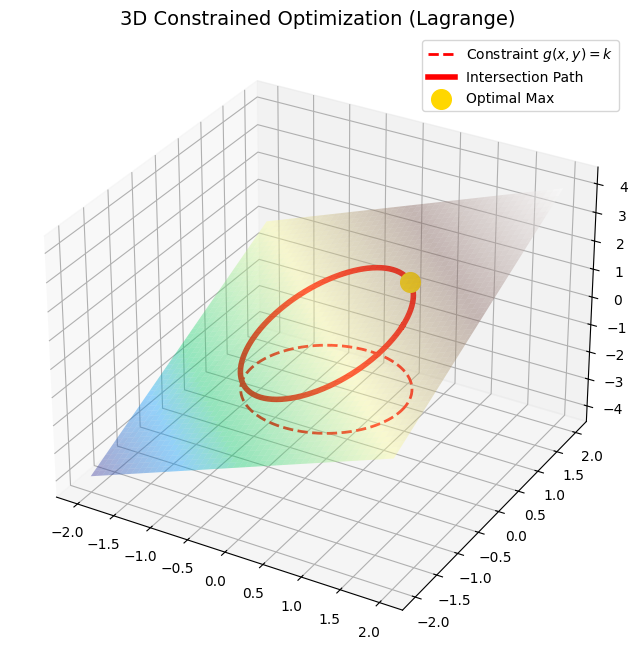

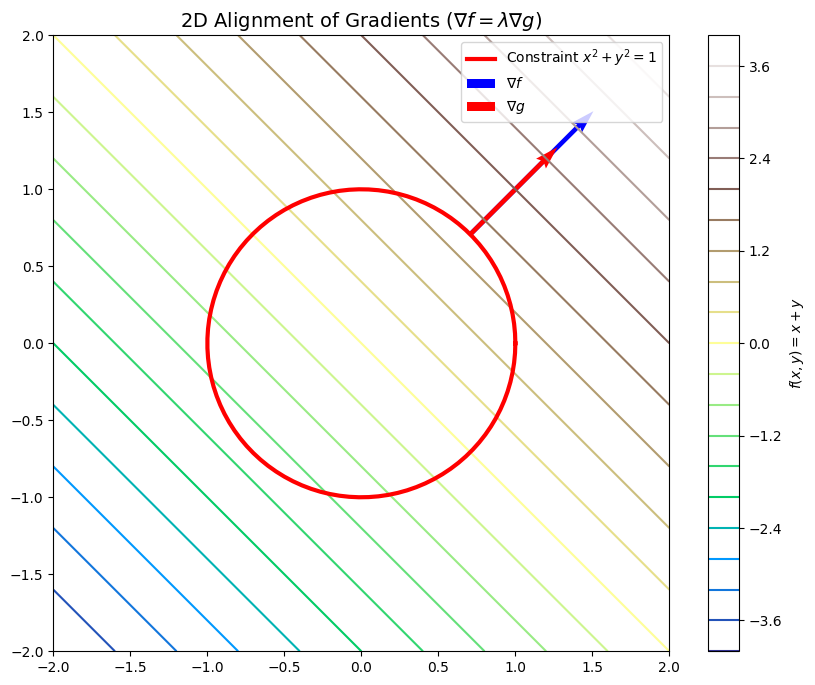

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import os

def generate_lagrange_assets():
    # Assets yolu
    asset_path = '../../../assets'
    if not os.path.exists(asset_path): os.makedirs(asset_path)

    # Veri Hazırlığı
    x = np.linspace(-2, 2, 100)
    y = np.linspace(-2, 2, 100)
    X, Y = np.meshgrid(x, y)
    Z = X + Y # Hedef fonksiyon f(x,y) = x + y
    
    # Kısıt: x^2 + y^2 = 1 (Birim Çember)
    theta = np.linspace(0, 2*np.pi, 100)
    cx = np.cos(theta)
    cy = np.sin(theta)
    cz = cx + cy # Kısıt üzerindeki z değerleri

    # --- FIGURE 1: 3D Visualization ---
    fig3d = plt.figure(figsize=(10, 8))
    ax3d = fig3d.add_subplot(111, projection='3d')
    # Hedef yüzey (yarı saydam)
    ax3d.plot_surface(X, Y, Z, cmap='terrain', alpha=0.4, edgecolor='none')
    # Kısıt Çemberi (Tabanda)
    ax3d.plot(cx, cy, -2, 'r--', lw=2, label='Constraint $g(x,y)=k$')
    # Kısıt altındaki fonksiyon yolu
    ax3d.plot(cx, cy, cz, 'r-', lw=4, label='Intersection Path')
    # Optimal Noktalar (Max/Min)
    ax3d.scatter([np.sqrt(2)/2], [np.sqrt(2)/2], [np.sqrt(2)], color='gold', s=200, label='Optimal Max')
    
    ax3d.set_title("3D Constrained Optimization (Lagrange)", fontsize=14)
    ax3d.legend()
    plt.savefig(f'{asset_path}/30_lagrange_3d.png', dpi=300)

    # --- FIGURE 2: 2D Contour & Gradient Alignment ---
    fig2d = plt.figure(figsize=(10, 8))
    ax2d = fig2d.add_subplot(111)
    cp = ax2d.contour(X, Y, Z, 20, cmap='terrain')
    plt.colorbar(cp, label='$f(x,y) = x+y$')
    # Kısıt çemberini çiz
    ax2d.plot(cx, cy, 'r-', lw=3, label='Constraint $x^2+y^2=1$')
    # Optimal noktada gradyanları göster (Örn: Max noktası)
    px, py = np.sqrt(2)/2, np.sqrt(2)/2
    ax2d.quiver(px, py, 1, 1, color='blue', scale=5, label='$\\nabla f$')
    ax2d.quiver(px, py, px, py, color='red', scale=5, label='$\\nabla g$')
    
    ax2d.set_title("2D Alignment of Gradients ($\\nabla f = \\lambda \\nabla g$)", fontsize=14)
    ax2d.set_aspect('equal')
    ax2d.legend()
    plt.savefig(f'{asset_path}/30_lagrange_2d.png', dpi=300)

    # --- MASTER DASHBOARD ---
    plt.show()

if __name__ == "__main__":
    generate_lagrange_assets()